<a href="https://colab.research.google.com/github/elinsyn/Fluid_mechanics/blob/main/Navier-Stokes-Barcelona.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Navier-Stokes equations**
**Johan Hoffman**

# **Abstract**

This short report show an example on how to use FEniCS to solve the Navier-Stokes equations, which is used in the course DD2365 Advanced Computation in Fluid Mechanics, at the KTH Royal Institute of Technology.

[DD2365 course website.](https://www.kth.se/social/course/DD2365/)

# **About the code**

In [28]:
# This program is an example file for the course
# DD2365 Advanced Computation in Fluid Mechanics,
# KTH Royal Institute of Technology, Stockholm, Sweden.

# Copyright (C) 2020 Johan Hoffman (jhoffman@kth.se)

# This file is part of the course DD2365 Advanced Computation in Fluid Mechanics
# KTH Royal Institute of Technology, Stockholm, Sweden
#
# This is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.

# This template is maintained by Johan Hoffman
# Please report problems to jhoffman@kth.se

# **Set up environment**

In [29]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# **Introduction**

The Navier-Stokes equations take the form

$\dot u + (u\cdot \nabla)u + \nabla p -\Delta u = f,\quad \nabla \cdot u=0,$

together with suitable initial and boundary conditions.

Here we present a FEniCS implementation of a stabilized space-time finite element method to solve the Navier-Stokes equations in 2D. The solution is visualized using FEniCS plotting functions, and is also exported as pvd-files which can be visualized in Paraview.

We seek a finite element approximation $(u,p)\in V\times Q$ such that

$(\dot u + (u\cdot \nabla)u, v) - (p,\nabla \cdot v) + (\nu \nabla u,\nabla v) + (\nabla \cdot u, q) + SD(u,p;v,q) = (f,v),$

for all test functions $(v,q) \in \hat V\times \hat Q$, where $SD(u,p;v,q)$ is a residual based stabilization term.

We present an example of flow past a circular cylinder, for which we compute the force on the surface of the cylinder $\Gamma$ in the direction $\phi$, by Green's formula:

$
F(u,p,\phi)= ~<\nu \nabla u\cdot n-pn, \Phi>_{\Gamma} ~=~(\dot u+(u\cdot \nabla)u, \Phi) + (\nu \nabla u,\nabla \Phi) - (p,\nabla \cdot\Phi)-(f,\Phi),
$

with $\Phi\in V$ a fuinction for which $\Phi\vert _{\Gamma}=\phi$ and $\Phi\vert_{\partial \Omega \setminus \Gamma}=0$. With $\phi=(1,0)$ we get the drag force $F_D$, and with $\phi=(0,1)$ the lift force $F_L$. The drag and lift coefficients are obtained by normalization,

$
c_D = \frac{2F_D}{\rho U^2D}, \quad c_L = \frac{2F_L}{\rho U^2D}
$

where $\rho$ is the density (here $\rho=1$), $U$ the characteristic velocity (here $U=1$), and $D$ the characteristic length scale (here $D$ is the diameter of the cylinder).

The Reynolds number is defined as $Re=\frac{UD}{\nu}$

To read more about how to use similar methods for more complex problems, see e.g.

[Hoffman, Johan, et al. "Towards a parameter-free method for high reynolds number turbulent flow simulation based on adaptive finite element approximation." Computer Methods in Applied Mechanics and Engineering 288 (2015): 60-74.](https://www.sciencedirect.com/science/article/pii/S0045782514004836)


# **Method**

**Define domain and mesh**

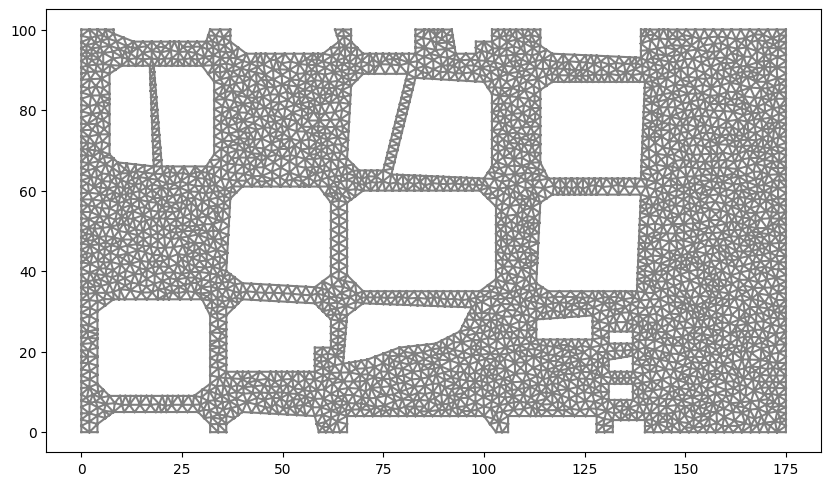

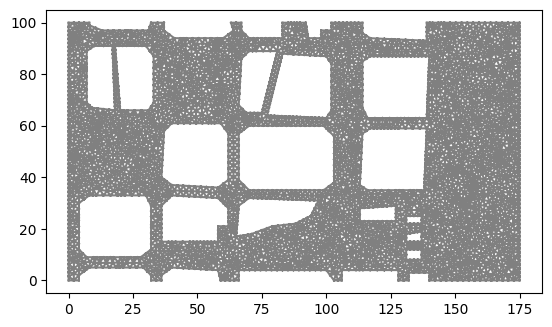

In [30]:
from dolfin import *
from mshr import *
import matplotlib.pyplot as plt

# Domain size
L = 175
H = 100

# ----------------------------
# Polygon vertex definitions
# ----------------------------

# Upper-wall attached objects
casa1_vertices = [(139, 100), (114, 100), (114, 96), (117, 94), (139, 93)]
casa2_vertices = [(102, 100), (92, 100), (93, 94), (98, 94), (98, 97), (102, 97)]
casa3_vertices = [(83, 100), (67, 100), (67, 97), (70, 94), (83, 94)]
casa4_vertices = [(63, 100), (37, 100), (37, 97), (41, 94), (60, 94), (64, 97)]
casa5_vertices = [(32, 100), (8, 100), (8, 99), (13, 97), (31, 97)]

# Middle objects
casa6_vertices  = [(140, 87), (117, 87), (114, 85), (114, 67), (116, 63), (139, 63)]
casa7_vertices  = [(100, 87), (83, 88), (77, 64), (100, 63), (102, 66), (102, 84)]
casa8_vertices  = [(81, 89), (70, 89), (67, 86), (66, 68), (69, 65), (75, 65)]
casa9_vertices  = [(30, 91), (18, 91), (20, 66), (31, 66), (33, 69), (33, 87)]
casa10_vertices = [(17, 91), (10, 91), (7, 89), (7, 69), (9, 67), (18, 66)]
casa11_vertices = [(139, 59), (117, 59), (114, 57), (113, 37), (116, 35), (138, 35)]
casa12_vertices = [(99, 60), (70, 60), (66, 57), (66, 39), (70, 35), (99, 35), (103, 38), (103, 56)]
casa13_vertices = [(59, 61), (40, 61), (37, 58), (36, 40), (40, 37), (58, 36), (62, 39), (62, 57)]
casa14_vertices = [(137, 25), (131, 25), (131, 22), (137, 22)]
casa15_vertices = [(137, 19), (131, 18), (131, 15), (137, 15)]
casa16_vertices = [(137, 12), (131, 12), (131, 8), (137, 8)]
casa17_vertices = [(127, 29), (113, 28), (113, 23), (127, 23)]
casa18_vertices = [(97, 31), (70, 32), (66, 29), (65, 17), (71, 18), (79, 21), (88, 22), (94, 25)]
casa19_vertices = [(58, 32), (40, 33), (36, 29), (36, 15), (58, 15), (58, 21), (62, 21), (62, 28)]
casa20_vertices = [(30, 33), (8, 33), (4, 30), (4, 12), (7, 9), (28, 9), (32, 12), (32, 29)]

# Lower-wall attached objects
casa21_vertices = [(140, 3), (132, 3), (132, 0), (140, 0)]
casa22_vertices = [(128, 4), (106, 4), (106, 0), (128, 0)]
casa23_vertices = [(100, 4), (66, 4), (66, 0), (103, 0)]
casa24_vertices = [(58, 4), (40, 5), (36, 2), (36, 0), (59, 0)]
casa25_vertices = [(29, 5), (8, 5), (4, 2), (4, 0), (32, 0), (32, 2)]

upper_vertices = [
    casa1_vertices, casa2_vertices, casa3_vertices, casa4_vertices, casa5_vertices]

middle_vertices = [
    casa6_vertices, casa7_vertices, casa8_vertices, casa9_vertices, casa10_vertices,
    casa11_vertices, casa12_vertices, casa13_vertices, casa14_vertices, casa15_vertices,
    casa16_vertices, casa17_vertices, casa18_vertices, casa19_vertices, casa20_vertices]

lower_vertices = [
    casa21_vertices, casa22_vertices, casa23_vertices, casa24_vertices, casa25_vertices]

all_vertices = upper_vertices + middle_vertices + lower_vertices

def make_polygon(vertices):
    return Polygon([Point(x, y) for x, y in vertices])

upper_objects = [make_polygon(v) for v in upper_vertices]
middle_objects = [make_polygon(v) for v in middle_vertices]
lower_objects = [make_polygon(v) for v in lower_vertices]

all_objects = upper_objects + middle_objects + lower_objects

# Fluid domain
domain = Rectangle(Point(0.0, 0.0), Point(L, H))

# Subtract all casas
for obj in all_objects:
    domain = domain - obj

resolution = 64
mesh = generate_mesh(domain, resolution)

plt.figure(figsize=(10, 7))
plot(mesh)
plt.show()

# Boundary IDs
INLET = 1
OUTLET = 2
UPPER_SLIP = 3
LOWER_SLIP = 4
MIDDLE_OBJECTS = 5

tol = 1e-6

def point_on_segment(x, p1, p2, tol=1e-6):
    x0, y0 = x[0], x[1]
    x1, y1 = p1
    x2, y2 = p2

    if x0 < min(x1, x2) - tol or x0 > max(x1, x2) + tol:
        return False
    if y0 < min(y1, y2) - tol or y0 > max(y1, y2) + tol:
        return False

    cross = abs((x0 - x1)*(y2 - y1) - (y0 - y1)*(x2 - x1))
    length = ((x2 - x1)**2 + (y2 - y1)**2)**0.5

    return cross <= tol*max(length, 1.0)


def point_on_polygon_boundary(x, vertices, tol=1e-6):
    n = len(vertices)
    for i in range(n):
        p1 = vertices[i]
        p2 = vertices[(i + 1) % n]
        if point_on_segment(x, p1, p2, tol):
            return True
    return False


def point_on_any_polygon_boundary(x, polygon_list, tol=1e-6):
    for vertices in polygon_list:
        if point_on_polygon_boundary(x, vertices, tol):
            return True
    return False

class InletBoundary(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0, tol)

class OutletBoundary(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], L, tol)

class UpperSlipBoundary(SubDomain):
    def inside(self, x, on_boundary):
        if not on_boundary:
            return False

        # Physical top wall
        if near(x[1], H, tol):
            return True

        # Upper-wall attached casas
        return point_on_any_polygon_boundary(x, upper_vertices, tol)


class LowerSlipBoundary(SubDomain):
    def inside(self, x, on_boundary):
        if not on_boundary:
            return False

        # Physical bottom wall
        if near(x[1], 0.0, tol):
            return True

        # Lower-wall attached casas
        return point_on_any_polygon_boundary(x, lower_vertices, tol)


class MiddleObjectsBoundary(SubDomain):
    def inside(self, x, on_boundary):
        if not on_boundary:
            return False

        return point_on_any_polygon_boundary(x, middle_vertices, tol)

inlet = InletBoundary()
outlet = OutletBoundary()
upper_slip = UpperSlipBoundary()
lower_slip = LowerSlipBoundary()
middle_objects_boundary = MiddleObjectsBoundary()

boundaries = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
boundaries.set_all(0)

inlet.mark(boundaries, INLET)
outlet.mark(boundaries, OUTLET)
upper_slip.mark(boundaries, UPPER_SLIP)
lower_slip.mark(boundaries, LOWER_SLIP)
middle_objects_boundary.mark(boundaries, MIDDLE_OBJECTS)

ds = Measure("ds", domain=mesh, subdomain_data=boundaries)

plt.figure()
plot(mesh)
plt.show()

**Define finite element approximation spaces**

In [31]:
# Generate finite element spaces (for velocity and pressure)
V = VectorFunctionSpace(mesh, "Lagrange", 1)
Q = FunctionSpace(mesh, "Lagrange", 1)

# Define trial and test functions
u = TrialFunction(V)
p = TrialFunction(Q)
v = TestFunction(V)
q = TestFunction(Q)

**Define boundary conditions**

In [32]:
# Define boundary conditions
class DirichletBoundaryLower(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], 0.0)

class DirichletBoundaryUpper(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], H)

class DirichletBoundaryLeft(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0)

class DirichletBoundaryRight(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], L)

class DirichletBoundaryObjects(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and (not near(x[0], 0.0)) and (not near(x[0], L)) and (not near(x[1], 0.0)) and (not near(x[1], H))


inlet = DirichletBoundaryRight()
outlet = DirichletBoundaryLeft()

uin = -1.0
bcu_in0 = DirichletBC(V.sub(0), Constant(uin), inlet)
bcu_in1 = DirichletBC(V.sub(1), Constant(0.0), inlet)

bcu = [bcu_in0, bcu_in1]

pin = Expression('5.0*fabs(sin(t))', element = Q.ufl_element(), t=0.0)
pout = 0.0
#bcp0 = DirichletBC(Q, pin, dbc_left)
bcp1 = DirichletBC(Q, pout, outlet)

bcp = [bcp1]

# Define measure for boundary integration
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

# **Results**

**Define flow parameters**

In [33]:
# Set viscosity
nu = 4.0e-3

**Define method parameters**

In [34]:
# Define iteration functions
# (u0,p0) solution from previous time step
# (u1,p1) linearized solution at present time step
u0 = Function(V)
u1 = Function(V)
p0 = Function(Q)
p1 = Function(Q)

# Set parameters for nonlinear and lienar solvers
num_nnlin_iter = 5
prec = "amg" if has_krylov_solver_preconditioner("amg") else "default"

# Time step length
dt = 0.5*mesh.hmin()

**Define variational problem**

In [35]:
# Define variational problem

n = FacetNormal(mesh)
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)
gamma_slip = Constant(1.0)

# Stabilization parameters
h = CellDiameter(mesh);
u_mag = sqrt(dot(u1,u1))
d1 = 1.0/sqrt((pow(1.0/dt,2.0) + pow(u_mag/h,2.0)))
d2 = h*u_mag

# Mean velocities for trapozoidal time stepping
um = 0.5*(u + u0)
um1 = 0.5*(u1 + u0)

# Momentum variational equation on residual form
Fu = inner((u - u0)/dt + grad(um)*um1, v)*dx \
    - p1*div(v)*dx \
    + nu*inner(grad(um), grad(v))*dx \
    + d1*inner((u - u0)/dt + grad(um)*um1 + grad(p1), grad(v)*um1)*dx \
    + d2*div(um)*div(v)*dx \
    + gamma_slip/h * dot(um, n)*dot(v, n)*ds(UPPER_SLIP) \
    + gamma_slip/h * dot(um, n)*dot(v, n)*ds(LOWER_SLIP) \
    + gamma_slip/h * dot(um, n)*dot(v, n)*ds(MIDDLE_OBJECTS)

au = lhs(Fu)
Lu = rhs(Fu)

# Continuity variational equation on residual form
Fp = d1*inner((u1 - u0)/dt + grad(um1)*um1 + grad(p), grad(q))*dx + div(um1)*q*dx
ap = lhs(Fp)
Lp = rhs(Fp)

**Triple decomposition**

In [36]:
import scipy.linalg.lapack as la
import numpy as np

def triple_decomposition(grad_u):
    new_grad = np.array([[0,0,0],
                         [0,0,0],
                         [0,0,0]])
    for i in range(2):
      for j in range(2):
        new_grad[i,j] = grad_u[i,j]
    def dselect(arg1,arg2): return (arg2==0)
    T = la.dgees(dselect,new_grad,sort_t = 1)[0]
    sh = np.linalg.norm([T[0,1],T[0,2],T[1,2]+T[2,1]])
    el = np.linalg.norm(np.diag(T))
    rr = np.sqrt(2*min(abs(T[1,2]),abs(T[2,1]))**2)
    return sh, el, rr

**Compute force on boundary**

In [37]:
# Define the direction of the force to be computed
phi_x = 0.0
phi_y = 1.0

#psi_expression = Expression(("0.0","pow(x[0]-0.5,2.0) + pow(x[1]-1.0,2.0) - pow(0.2,2.0) < 1.e-5 ? 1. : 0."), element = V.ufl_element())
#psi_expression = Expression(("near(pow(x[0]-xc,2.0) + pow(x[1]-yc,2.0) - pow(rc,2.0), 0.0) ? phi_x : 0.","near(pow(x[0]-xc,2.0) + pow(x[1]-yc,2.0) - pow(rc,2.0), 0.0) ? phi_y : 0."), xc=xc, yc=yc, rc=rc, phi_x=phi_x, phi_y=phi_y, element = V.ufl_element())
#psi = interpolate(psi_expression, V)

#Force = inner((u1 - u0)/dt + grad(um1)*um1, psi)*dx - p1*div(psi)*dx + nu*inner(grad(um1), grad(psi))*dx

#plt.figure()
#plot(psi, title="weight function psi")

# Force normalization
#D = 2*rc
#normalization = -2.0/D

**Set plotting variables and open export files**

In [38]:
# Open files to export solution to Paraview
file_u = File("results-NS/u.pvd")
file_p = File("results-NS/p.pvd")

# Set plot frequency
plot_time = 0
plot_freq = 10

# Force computation data
force_array = np.array(0.0)
force_array = np.delete(force_array, 0)
time = np.array(0.0)
time = np.delete(time, 0)
start_sample_time = 1.0

**Time stepping algorithm**

In [39]:
!rm results-NS/*

# Time stepping
T = 30
t = dt
while t < T + DOLFIN_EPS:

    #s = 'Time t = ' + repr(t)
    #print(s)

    pin.t = t
    #uin.t = t

    # Solve non-linear problem
    k = 0
    while k < num_nnlin_iter:

        # Assemble momentum matrix and vector
        Au = assemble(au)
        bu = assemble(Lu)

        # Compute velocity solution
        [bc.apply(Au, bu) for bc in bcu]
        [bc.apply(u1.vector()) for bc in bcu]
        solve(Au, u1.vector(), bu, "bicgstab", "default")

        # Assemble continuity matrix and vector
        Ap = assemble(ap)
        bp = assemble(Lp)

        # Compute pressure solution
        [bc.apply(Ap, bp) for bc in bcp]
        [bc.apply(p1.vector()) for bc in bcp]
        solve(Ap, p1.vector(), bp, "bicgstab", prec)

        # Compute force
        #F = assemble(Force)
        if (t > start_sample_time):
          force_array = np.append(force_array, normalization*F)
          time = np.append(time, t)

        k += 1

    if t > plot_time:

        s = 'Time t = ' + repr(t)
        print(s)

        # Save solution to file
        file_u << u1
        file_p << p1

        # Triple decomposition
        V = TensorFunctionSpace(mesh, 'P', 1)
        grad_u1_prel = nabla_grad(u1)
        grad_u1 = project(grad_u1_prel, V)

        V2 = FunctionSpace(mesh, 'CG', 1)
        shear = Function(V2)
        elongation = Function(V2)
        rotation = Function(V2)
        dofmap = V2.dofmap()

        # Divergence
        divu = Function(V2)

        for vertex in vertices(mesh):
            point = vertex.point()
            grad_u1_point = grad_u1(point) # Evaluate the gradient tensor at the current point
            grad_u1_matrix = matrix = np.array([
                                                [grad_u1_point[0],grad_u1_point[1] ],
                                                [grad_u1_point[2], grad_u1_point[3]]
                                                                                       ])
            sh, el, rr = triple_decomposition(grad_u1_matrix)
            vertex_index = vertex.index()
            dof_index = vertex_to_dof_map(V2)[vertex_index]
            shear.vector()[dof_index] = sh
            elongation.vector()[dof_index] = el
            rotation.vector()[dof_index] = rr

            divu_vert = grad_u1_point[0] + grad_u1_point[3]
            divu.vector()[dof_index] = divu_vert

        # Plot Triple Decomposition
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        ax = plt.subplot(1, 3, 1)
        im = plot(shear, title = "Shear")
        plt.colorbar(im)
        ax = plt.subplot(1, 3, 2)
        im = plot(elongation, title = "Strain")
        plt.colorbar(im)
        ax = plt.subplot(1, 3, 3)
        im = plot(rotation, title = "Rotation")
        plt.colorbar(im)
        plt.tight_layout()
        plt.show()

        # Plot divergence
        plt.figure()
        im = plot(divu, title="divergence")
        plt.colorbar(im)

        # Plot solution
        plt.figure()
        plot(u1, title="Velocity")

        plt.figure()
        plot(p1, title="Pressure")

        plot_time += T/plot_freq

        plt.show()

        #plt.figure()
        #plt.title("Force")
        #plt.plot(time, force_array)
        #plt.show()

    # Update time step
    u0.assign(u1)
    t += dt

#!tar -czvf results-NS.tar.gz results-NS
#files.download('results-NS.tar.gz')

rm: cannot remove 'results-NS/*': No such file or directory


RuntimeError: 

*** -------------------------------------------------------------------------
*** DOLFIN encountered an error. If you are not able to resolve this issue
*** using the information listed below, you can ask for help at
***
***     https://fenicsproject.discourse.group/
***
*** Remember to include the error message listed below and, if possible,
*** include a *minimal* running example to reproduce the error.
***
*** -------------------------------------------------------------------------
*** Error:   Unable to solve linear system using PETSc Krylov solver.
*** Reason:  Solution failed to converge in 10000 iterations (PETSc reason DIVERGED_ITS, residual norm ||r|| = 8.443549e+14).
*** Where:   This error was encountered inside PETScKrylovSolver.cpp.
*** Process: 0
*** 
*** DOLFIN version: 2019.2.0.dev0
*** Git changeset:  a8dcf753d3ab9ae19d7bedf8c634a4fe545032d2
*** -------------------------------------------------------------------------


# **Discussion**

A stabilized finite element method was implemented in FEniCS to solve the Navier-Stokes equations in 2D. The method was tested for the model problem of flow past a circular obstacle, and for a high enough Reynolds number and sufficient mesh resolution [a von Karman vortex street developed as expected.](https://en.wikipedia.org/wiki/Kármán_vortex_street)